In [1]:
import sys
import subprocess

def ensure_package(pip_name, import_name=None):
    import_name = import_name or pip_name
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing missing package: {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        print(f"  {pip_name} installed.")

for pip_name, import_name in [
    ("pandas", "pandas"),
    ("xlrd", "xlrd"),
    ("matplotlib", "matplotlib"),
    ("scikit-learn", "sklearn"),
]:
    ensure_package(pip_name, import_name)

In [2]:
import os
import json
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.utils import resample

# Folders are relative to this script/notebook's own location.
DATA = "data"
FIG = "figs"
os.makedirs(FIG, exist_ok=True)
os.makedirs(DATA, exist_ok=True)

In [3]:
RAW_SOURCES = {
    "saipe_income.xls":
        "https://www2.census.gov/programs-surveys/saipe/datasets/2023/2023-state-and-county/est23all.xls",
    "cc_est2023_raw.csv":
        "https://www2.census.gov/programs-surveys/popest/datasets/2020-2023/counties/asrh/cc-est2023-alldata.csv",
    "aqs_monitors.zip":
        "https://aqs.epa.gov/aqsweb/airdata/aqs_monitors.zip",
    "aqi_county_2024.zip":
        "https://aqs.epa.gov/aqsweb/airdata/annual_aqi_by_county_2024.zip",
}

req_headers = {"User-Agent": "Mozilla/5.0 (compatible; NCI-H9ETS-CA/1.0)"}

for filename, url in RAW_SOURCES.items():
    local_path = f"{DATA}/{filename}"
    if os.path.exists(local_path) and os.path.getsize(local_path) > 0:
        print(f"Already have {filename} ({os.path.getsize(local_path)/1e6:.1f} MB) — skipping download")
        continue
    print(f"Downloading {filename} from {url} ...")
    request = urllib.request.Request(url, headers=req_headers)
    with urllib.request.urlopen(request) as response, open(local_path, "wb") as out_file:
        out_file.write(response.read())
    print(f"  saved {filename} ({os.path.getsize(local_path)/1e6:.1f} MB)")

print("\nAll raw datasets present in", os.path.abspath(DATA))

Already have saipe_income.xls (1.1 MB) — skipping download
Already have cc_est2023_raw.csv (74.4 MB) — skipping download
Already have aqs_monitors.zip (6.9 MB) — skipping download
Already have aqi_county_2024.zip (0.0 MB) — skipping download

All raw datasets present in E:\NCI\Sem3\Emerging AI Tech\Part2_Code\data


In [4]:
STATE_ABBR = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
    'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District of Columbia': 'DC',
    'Puerto Rico': 'PR',
}

In [5]:
# ---- 1a. Income / poverty (SAIPE) ----
saipe = pd.read_excel(f"{DATA}/saipe_income.xls", header=3)
saipe = saipe.rename(columns={
    "State FIPS Code": "state_fips",
    "County FIPS Code": "county_fips",
    "Name": "county_name",
    "Poverty Percent, All Ages": "poverty_pct",
    "Median Household Income": "median_income",
})
saipe = saipe[saipe["county_fips"] != 0]  # drop state/national summary rows
saipe["state_fips"] = saipe["state_fips"].astype(int).astype(str).str.zfill(2)
saipe["county_fips"] = saipe["county_fips"].astype(int).astype(str).str.zfill(3)
saipe["fips"] = saipe["state_fips"] + saipe["county_fips"]
saipe = saipe[["fips", "county_name", "Postal Code", "poverty_pct", "median_income"]] \
    .rename(columns={"Postal Code": "state_abbr"})
saipe["poverty_pct"] = pd.to_numeric(saipe["poverty_pct"], errors="coerce")
saipe["median_income"] = pd.to_numeric(saipe["median_income"], errors="coerce")

# ---- 1b. Population / race ----
pop = pd.read_csv(f"{DATA}/cc_est2023_raw.csv", encoding="latin1")
pop = pop[(pop["AGEGRP"] == 0) & (pop["YEAR"] == pop["YEAR"].max())].copy()
pop["fips"] = pop["STATE"].astype(str).str.zfill(2) + pop["COUNTY"].astype(str).str.zfill(3)
pop["total_pop"] = pop["TOT_POP"]
pop["white_nh_pop"] = pop["NHWA_MALE"] + pop["NHWA_FEMALE"]
pop["minority_pct"] = 100 * (1 - pop["white_nh_pop"] / pop["total_pop"])
pop["black_pct"] = 100 * (pop["BA_MALE"] + pop["BA_FEMALE"]) / pop["total_pop"]
pop["hispanic_pct"] = 100 * (pop["H_MALE"] + pop["H_FEMALE"]) / pop["total_pop"]
pop = pop[["fips", "total_pop", "minority_pct", "black_pct", "hispanic_pct"]]

# ---- 1c. Active AQI monitors per county ----
with zipfile.ZipFile(f"{DATA}/aqs_monitors.zip") as z:
    with z.open("aqs_monitors.csv") as f:
        mon = pd.read_csv(f, low_memory=False)

mon["Last Sample Date"] = pd.to_datetime(mon["Last Sample Date"], errors="coerce")
active = mon[mon["Last Sample Date"] >= "2023-01-01"].copy()
active["fips"] = active["State Code"].astype(str).str.zfill(2) + active["County Code"].astype(str).str.zfill(3)
site_counts = (active.drop_duplicates(subset=["fips", "Site Number"])
               .groupby("fips").size().reset_index(name="monitor_count"))

# ---- 1d. Merge into one county master table ----
df = saipe.merge(pop, on="fips", how="inner").merge(site_counts, on="fips", how="left")
df["monitor_count"] = df["monitor_count"].fillna(0).astype(int)
df["has_monitor"] = (df["monitor_count"] > 0).astype(int)
df["monitors_per_100k"] = df["monitor_count"] / (df["total_pop"] / 100000)

df = df.dropna(subset=["poverty_pct", "median_income", "minority_pct", "total_pop"])
df = df[df["total_pop"] > 0]

print("Final merged county count:", len(df))
df.to_csv(f"{DATA}/county_master.csv", index=False)

Final merged county count: 3143


In [6]:
df["county_clean"] = (df["county_name"].str.strip()
                       .str.replace(r"\s+(County|Parish|Borough|Municipio|city|Census Area|Municipality)$",
                                    "", regex=True)
                       .str.strip().str.lower())

with zipfile.ZipFile(f"{DATA}/aqi_county_2024.zip") as z:
    with z.open("annual_aqi_by_county_2024.csv") as f:
        aqi = pd.read_csv(f)
aqi["state_abbr"] = aqi["State"].map(STATE_ABBR)
aqi["county_clean"] = aqi["County"].str.strip().str.lower()
aqi = aqi[["state_abbr", "county_clean", "Median AQI", "Days with AQI"]] \
    .rename(columns={"Median AQI": "median_aqi"})

df = df.merge(aqi, on=["state_abbr", "county_clean"], how="left")
print("Counties with AQI value matched:", df["median_aqi"].notna().sum(), "/", len(df))

Counties with AQI value matched: 963 / 3143


In [7]:
summary = df[["poverty_pct", "median_income", "minority_pct", "black_pct", "hispanic_pct",
              "total_pop", "monitor_count", "has_monitor"]].describe()
summary.to_csv(f"{FIG}/summary_stats.csv")
summary

,poverty_pct,median_income,minority_pct,black_pct,hispanic_pct,total_pop,monitor_count,has_monitor
count,3143.000000,3143.000000,3143.000000,3143.000000,3143.000000,3.143000e+03,3143.000000,3143.000000
mean,14.491569,65561.641425,25.430307,9.499895,10.528891,1.065590e+05,0.802100,0.333758
std,5.552983,16543.495767,20.174472,14.308014,13.876147,3.326192e+05,2.178895,0.471629
min,3.300000,28579.000000,2.458140,0.000000,0.249969,4.300000e+01,0.000000,0.000000
25%,10.600000,54616.000000,8.927030,1.086999,2.881665,1.076550e+04,0.000000,0.000000
50%,13.600000,62851.000000,18.549998,2.777778,5.270328,2.598200e+04,0.000000,0.000000
75%,17.400000,73073.500000,37.436225,11.029175,11.543356,6.955200e+04,1.000000,1.000000
max,49.600000,173655.000000,97.517214,86.480214,96.981830,9.663345e+06,49.000000,1.000000


### Figure 1: the headline stat — overall monitoring coverage

Before slicing by income or race, just look at the raw picture: how many of the
3,143 US counties have an active monitor at all?

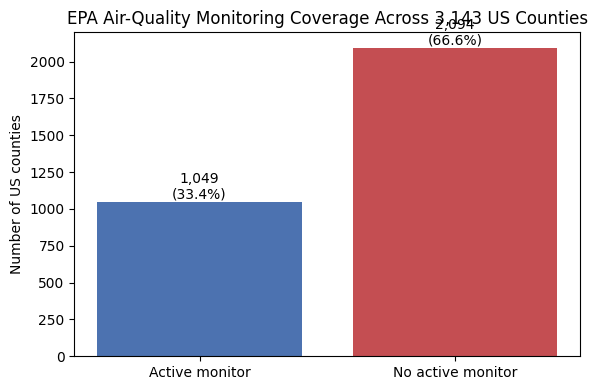

1,049 of 3,143 counties (33.4%) have an active monitor.


In [8]:
n_total = len(df)
n_monitored = int(df["has_monitor"].sum())
n_unmonitored = n_total - n_monitored

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Active monitor", "No active monitor"], [n_monitored, n_unmonitored],
              color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Number of US counties")
ax.set_title(f"EPA Air-Quality Monitoring Coverage Across {n_total:,} US Counties")
for b, v in zip(bars, [n_monitored, n_unmonitored]):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({100*v/n_total:.1f}%)", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{FIG}/fig0_overall_coverage.png", dpi=150)
plt.show()
print(f"{n_monitored:,} of {n_total:,} counties ({100*n_monitored/n_total:.1f}%) have an active monitor.")

In [9]:
df["minority_q"] = pd.qcut(df["minority_pct"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
df["poverty_q"] = pd.qcut(df["poverty_pct"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
df["income_q"] = pd.qcut(df["median_income"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])

cov_by_minority = df.groupby("minority_q", observed=True)["has_monitor"].mean() * 100
cov_by_poverty = df.groupby("poverty_q", observed=True)["has_monitor"].mean() * 100
cov_by_income = df.groupby("income_q", observed=True)["has_monitor"].mean() * 100

print("Coverage % by minority quartile:\n", cov_by_minority)
print("\nCoverage % by poverty quartile:\n", cov_by_poverty)
print("\nCoverage % by income quartile:\n", cov_by_income)

Coverage % by minority quartile:
 minority_q
Q1 (lowest)     19.847328
Q2              33.969466
Q3              41.401274
Q4 (highest)    38.295165
Name: has_monitor, dtype: float64

Coverage % by poverty quartile:
 poverty_q
Q1 (lowest)     41.676942
Q2              37.387964
Q3              32.600259
Q4 (highest)    21.465296
Name: has_monitor, dtype: float64

Coverage % by income quartile:
 income_q
Q1 (lowest)     15.139949
Q2              29.389313
Q3              34.522293
Q4 (highest)    54.452926
Name: has_monitor, dtype: float64


In [10]:
# Population-weighted view: % of PEOPLE (not counties) living somewhere with no monitor
pop_weighted = df.groupby("minority_q", observed=True).apply(
    lambda g: 100 * (g.loc[g["has_monitor"] == 0, "total_pop"].sum() / g["total_pop"].sum())
)
print("% of population in UNMONITORED counties, by minority quartile:\n", pop_weighted)

% of population in UNMONITORED counties, by minority quartile:
 minority_q
Q1 (lowest)     62.593744
Q2              40.648488
Q3              19.511457
Q4 (highest)    10.242523
dtype: float64


In [11]:
# Logistic regression: does race/poverty/income predict monitor presence, once we
# control for county population size (bigger counties get monitors regardless)?
X = df[["minority_pct", "poverty_pct", "median_income"]].copy()
X["log_pop"] = np.log(df["total_pop"])
X["median_income"] = X["median_income"] / 1000  # scale to comparable units
y = df["has_monitor"]

logit = LogisticRegression(max_iter=1000)
logit.fit(X, y)
coefs = pd.Series(logit.coef_[0], index=X.columns)
odds_ratios = np.exp(coefs)
print("Odds ratios (has_monitor ~ minority_pct + poverty_pct + income + log_pop):")
print(odds_ratios)

Odds ratios (has_monitor ~ minority_pct + poverty_pct + income + log_pop):
minority_pct     1.001483
poverty_pct      0.985244
median_income    1.007416
log_pop          2.641947
dtype: float64


### Figures 1–4: visualising the bias

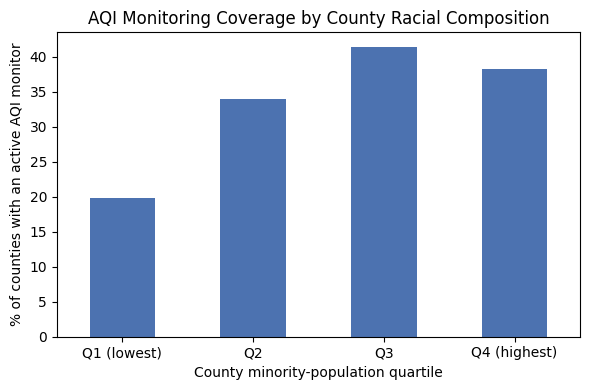

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
cov_by_minority.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("% of counties with an active AQI monitor")
ax.set_xlabel("County minority-population quartile")
ax.set_title("AQI Monitoring Coverage by County Racial Composition")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG}/fig1_coverage_by_minority.png", dpi=150)
plt.show()

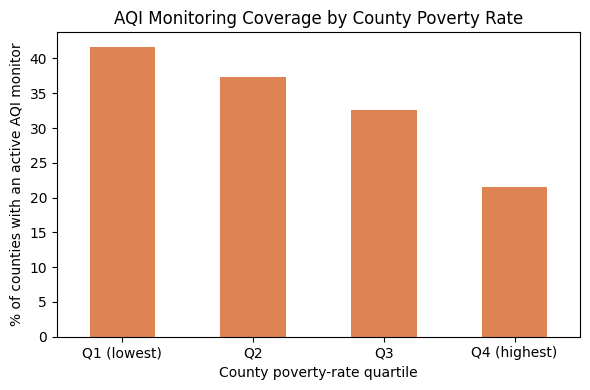

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
cov_by_poverty.plot(kind="bar", ax=ax, color="#DD8452")
ax.set_ylabel("% of counties with an active AQI monitor")
ax.set_xlabel("County poverty-rate quartile")
ax.set_title("AQI Monitoring Coverage by County Poverty Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG}/fig2_coverage_by_poverty.png", dpi=150)
plt.show()

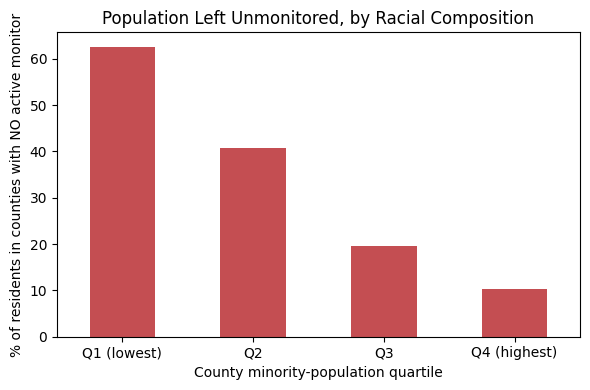

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
pop_weighted.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_ylabel("% of residents in counties with NO active monitor")
ax.set_xlabel("County minority-population quartile")
ax.set_title("Population Left Unmonitored, by Racial Composition")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG}/fig3_population_unmonitored.png", dpi=150)
plt.show()

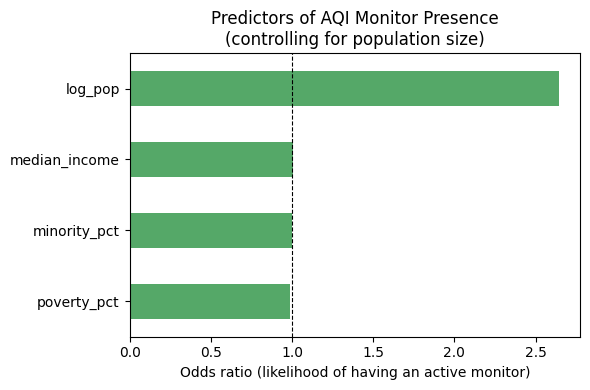

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
odds_ratios.sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Odds ratio (likelihood of having an active monitor)")
ax.set_title("Predictors of AQI Monitor Presence\n(controlling for population size)")
plt.tight_layout()
plt.savefig(f"{FIG}/fig4_odds_ratios.png", dpi=150)
plt.show()

## Step 4 — Model + bias mitigation

Simulate a realistic real-world bias: train an AQI-prediction model only on
low-poverty counties (as if high-poverty counties were simply under-sampled/under-
monitored, which is what Step 3 showed happens in practice), then test it on
high-poverty counties. Compare a naive baseline against two mitigation techniques.

In [16]:
model_df = df.dropna(subset=["median_aqi"]).copy()
print("Counties usable for modeling (have median_aqi):", len(model_df))

model_df["log_pop"] = np.log(model_df["total_pop"])
feat_cols = ["log_pop", "minority_pct", "poverty_pct", "median_income"]

median_poverty = model_df["poverty_pct"].median()
low_poverty = model_df[model_df["poverty_pct"] <= median_poverty]
high_poverty = model_df[model_df["poverty_pct"] > median_poverty]
print(f"Low-poverty (train) counties: {len(low_poverty)}, High-poverty (test) counties: {len(high_poverty)}")

X_train, y_train = low_poverty[feat_cols], low_poverty["median_aqi"]
X_test, y_test = high_poverty[feat_cols], high_poverty["median_aqi"]

# --- Baseline model (no mitigation) ---
baseline = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=6)
baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)
mae_baseline = mean_absolute_error(y_test, pred_baseline)

Counties usable for modeling (have median_aqi): 963
Low-poverty (train) counties: 484, High-poverty (test) counties: 479


In [17]:
# --- Mitigation 1: inverse-propensity reweighting ---
# Upweight low-poverty counties whose profile "looks like" a high-poverty county,
# so the training sample better represents the population it will be tested on.
prop_X = model_df[feat_cols]
prop_y = (model_df["poverty_pct"] <= median_poverty).astype(int)
prop_model = LogisticRegression(max_iter=1000)
prop_model.fit(prop_X, prop_y)
propensity = prop_model.predict_proba(X_train)[:, 1]
propensity = np.clip(propensity, 0.05, 0.95)
sample_weights = (1 - propensity) / propensity

reweighted = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=6)
reweighted.fit(X_train, y_train, sample_weight=sample_weights)
pred_reweighted = reweighted.predict(X_test)
mae_reweighted = mean_absolute_error(y_test, pred_reweighted)

# --- Mitigation 2: oversample counties near the high-poverty boundary ---
threshold = low_poverty["poverty_pct"].quantile(0.75)
near_boundary = low_poverty[low_poverty["poverty_pct"] >= threshold]
oversampled_extra = resample(near_boundary, replace=True, n_samples=len(near_boundary) * 3, random_state=42)
train_oversampled = pd.concat([low_poverty, oversampled_extra])
X_train_os, y_train_os = train_oversampled[feat_cols], train_oversampled["median_aqi"]

oversampled_model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=6)
oversampled_model.fit(X_train_os, y_train_os)
pred_oversampled = oversampled_model.predict(X_test)
mae_oversampled = mean_absolute_error(y_test, pred_oversampled)

print("=== MODEL PERFORMANCE ON HELD-OUT HIGH-POVERTY COUNTIES ===")
print(f"Baseline (naive, low-poverty only):        MAE = {mae_baseline:.3f}")
print(f"Mitigation 1 (inverse-propensity reweight): MAE = {mae_reweighted:.3f}")
print(f"Mitigation 2 (oversample near-boundary):    MAE = {mae_oversampled:.3f}")

=== MODEL PERFORMANCE ON HELD-OUT HIGH-POVERTY COUNTIES ===
Baseline (naive, low-poverty only):        MAE = 7.728
Mitigation 1 (inverse-propensity reweight): MAE = 7.567
Mitigation 2 (oversample near-boundary):    MAE = 7.566


### Flowchart: the baseline + mitigation pipeline

A visual summary of the cell above — the exact steps that produced the MAE
numbers just printed.

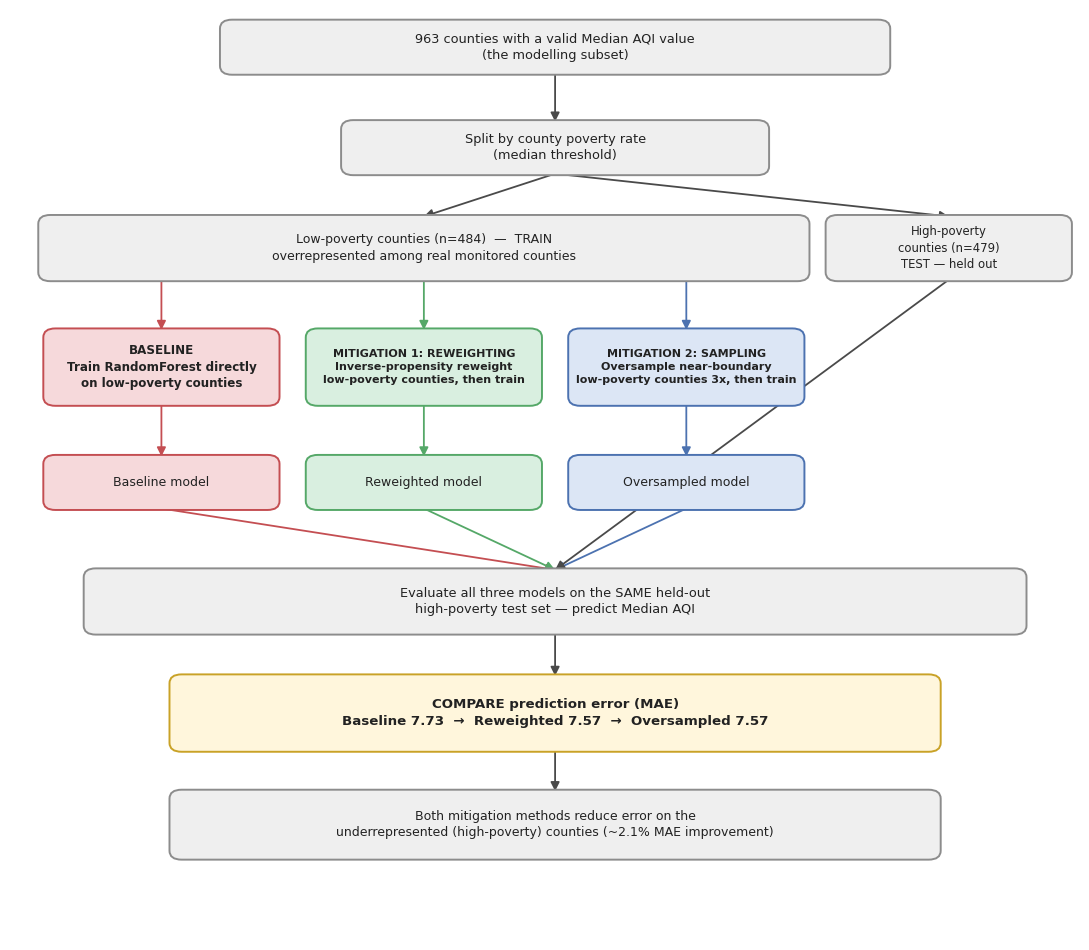

In [18]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

GRAY = "#4A4A4A"
NEUTRAL_FILL, NEUTRAL_EDGE = "#EFEFEF", "#8C8C8C"
BASE_FILL, BASE_EDGE = "#F6D9DB", "#C44E52"
M1_FILL, M1_EDGE = "#D9EFE0", "#55A868"
M2_FILL, M2_EDGE = "#DCE6F5", "#4C72B0"

fig, ax = plt.subplots(figsize=(11, 9.6))
ax.set_xlim(0, 10.6)
ax.set_ylim(0, 12.5)
ax.axis("off")

def _box(cx, cy, w, h, text, fill, edge, fontsize=8.6, fontweight="normal"):
    b = FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                        boxstyle="round,pad=0.02,rounding_size=0.12",
                        linewidth=1.4, edgecolor=edge, facecolor=fill, zorder=2)
    ax.add_patch(b)
    ax.text(cx, cy, text, ha="center", va="center", fontsize=fontsize,
             fontweight=fontweight, color="#222222", zorder=3, linespacing=1.35)
    return (cx, cy, w, h)

def _arrow(b_from, b_to, from_side="bottom", to_side="top", color=GRAY, lw=1.3, from_x=None):
    fx, fy, fw, fh = b_from
    tx, ty, tw, th = b_to
    pts = {"bottom": (fx, fy-fh/2), "top": (fx, fy+fh/2), "left": (fx-fw/2, fy), "right": (fx+fw/2, fy)}
    pts_to = {"bottom": (tx, ty-th/2), "top": (tx, ty+th/2), "left": (tx-tw/2, ty), "right": (tx+tw/2, ty)}
    start = pts[from_side]
    if from_x is not None:
        start = (from_x, start[1])
    end = pts_to[to_side]
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=13,
                                  linewidth=lw, color=color, zorder=1, shrinkA=0, shrinkB=0))

x_base, x_m1, x_m2, x_test = 1.5, 4.1, 6.7, 9.3
colw = 2.3

n0 = _box(5.4, 12.0, 6.6, 0.7, f"{len(model_df)} counties with a valid Median AQI value\n(the modelling subset)",
          NEUTRAL_FILL, NEUTRAL_EDGE, fontsize=9.3)
n1 = _box(5.4, 10.65, 4.2, 0.7, "Split by county poverty rate\n(median threshold)", NEUTRAL_FILL, NEUTRAL_EDGE, fontsize=9.3)
_arrow(n0, n1)

n2a = _box(4.1, 9.3, 7.6, 0.85, f"Low-poverty counties (n={len(low_poverty)})  —  TRAIN\noverrepresented among real monitored counties",
           NEUTRAL_FILL, NEUTRAL_EDGE, fontsize=9.0)
n2b = _box(x_test, 9.3, 2.4, 0.85, f"High-poverty\ncounties (n={len(high_poverty)})\nTEST — held out", NEUTRAL_FILL, NEUTRAL_EDGE, fontsize=8.4)
_arrow(n1, n2a, to_side="top")
_arrow(n1, n2b, to_side="top")

b1 = _box(x_base, 7.7, colw, 1.0, "BASELINE\nTrain RandomForest directly\non low-poverty counties", BASE_FILL, BASE_EDGE, fontweight="bold")
b2 = _box(x_m1, 7.7, colw, 1.0, "MITIGATION 1: REWEIGHTING\nInverse-propensity reweight\nlow-poverty counties, then train", M1_FILL, M1_EDGE, fontsize=8.0, fontweight="bold")
b3 = _box(x_m2, 7.7, colw, 1.0, "MITIGATION 2: SAMPLING\nOversample near-boundary\nlow-poverty counties 3x, then train", M2_FILL, M2_EDGE, fontsize=8.0, fontweight="bold")
_arrow(n2a, b1, from_side="bottom", to_side="top", color=BASE_EDGE, from_x=x_base)
_arrow(n2a, b2, from_side="bottom", to_side="top", color=M1_EDGE, from_x=x_m1)
_arrow(n2a, b3, from_side="bottom", to_side="top", color=M2_EDGE, from_x=x_m2)

m1n = _box(x_base, 6.15, colw, 0.7, "Baseline model", BASE_FILL, BASE_EDGE, fontsize=9)
m2n = _box(x_m1, 6.15, colw, 0.7, "Reweighted model", M1_FILL, M1_EDGE, fontsize=9)
m3n = _box(x_m2, 6.15, colw, 0.7, "Oversampled model", M2_FILL, M2_EDGE, fontsize=9)
_arrow(b1, m1n, color=BASE_EDGE)
_arrow(b2, m2n, color=M1_EDGE)
_arrow(b3, m3n, color=M2_EDGE)

ev = _box(5.4, 4.55, 9.3, 0.85, "Evaluate all three models on the SAME held-out\nhigh-poverty test set — predict Median AQI",
          NEUTRAL_FILL, NEUTRAL_EDGE, fontsize=9.3)
_arrow(m1n, ev, color=BASE_EDGE)
_arrow(m2n, ev, color=M1_EDGE)
_arrow(m3n, ev, color=M2_EDGE)
_arrow(n2b, ev, from_side="bottom", to_side="top", color=GRAY)

cp = _box(5.4, 3.05, 7.6, 1.0,
          f"COMPARE prediction error (MAE)\nBaseline {mae_baseline:.2f}  →  Reweighted {mae_reweighted:.2f}  →  Oversampled {mae_oversampled:.2f}",
          "#FFF6DC", "#C9A227", fontsize=9.6, fontweight="bold")
_arrow(ev, cp)

imp_rw = 100 * (mae_baseline - mae_reweighted) / mae_baseline
concl = _box(5.4, 1.55, 7.6, 0.9,
             f"Both mitigation methods reduce error on the\nunderrepresented (high-poverty) counties (~{imp_rw:.1f}% MAE improvement)",
             NEUTRAL_FILL, NEUTRAL_EDGE, fontsize=9.0)
_arrow(cp, concl)

plt.tight_layout()
plt.savefig(f"{FIG}/fig_flowchart_pipeline.png", dpi=200, bbox_inches="tight")
plt.show()

### Figures 5–6: did the mitigation actually help?

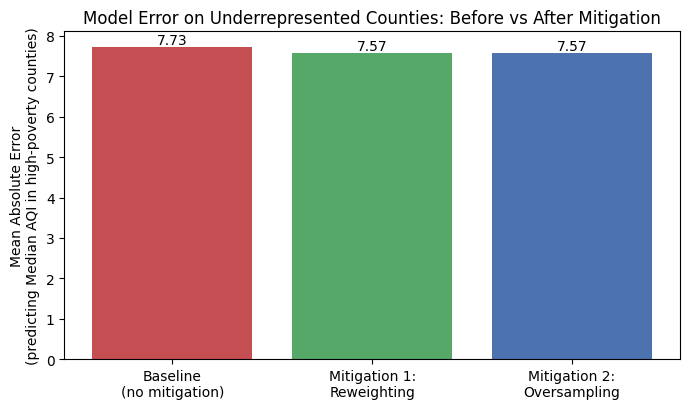

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.2))
methods = ["Baseline\n(no mitigation)", "Mitigation 1:\nReweighting", "Mitigation 2:\nOversampling"]
maes = [mae_baseline, mae_reweighted, mae_oversampled]
bars = ax.bar(methods, maes, color=["#C44E52", "#55A868", "#4C72B0"])
ax.set_ylabel("Mean Absolute Error\n(predicting Median AQI in high-poverty counties)")
ax.set_title("Model Error on Underrepresented Counties: Before vs After Mitigation", fontsize=12)
for b, v in zip(bars, maes):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{FIG}/fig5_mae_comparison.png", dpi=150)
plt.show()

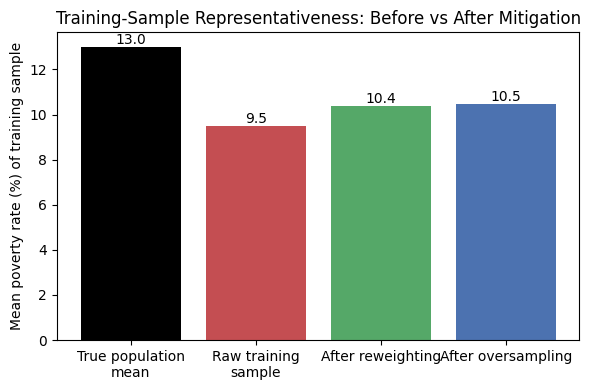

In [20]:
true_mean_poverty = model_df["poverty_pct"].mean()
raw_train_mean = low_poverty["poverty_pct"].mean()
reweighted_mean = np.average(low_poverty["poverty_pct"], weights=sample_weights)
oversampled_mean = train_oversampled["poverty_pct"].mean()

fig, ax = plt.subplots(figsize=(6, 4))
labels = ["True population\nmean", "Raw training\nsample", "After reweighting", "After oversampling"]
vals = [true_mean_poverty, raw_train_mean, reweighted_mean, oversampled_mean]
bars = ax.bar(labels, vals, color=["black", "#C44E52", "#55A868", "#4C72B0"])
ax.set_ylabel("Mean poverty rate (%) of training sample")
ax.set_title("Training-Sample Representativeness: Before vs After Mitigation")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{FIG}/fig6_representativeness.png", dpi=150)
plt.show()

## Step 5 — Save all key numbers (used directly in the Part 2 report)

In [21]:
results = {
    "n_counties_total": len(df),
    "n_counties_monitored": int(df["has_monitor"].sum()),
    "pct_counties_monitored": 100 * df["has_monitor"].mean(),
    "cov_by_minority_q1": cov_by_minority.iloc[0],
    "cov_by_minority_q4": cov_by_minority.iloc[-1],
    "cov_by_poverty_q1": cov_by_poverty.iloc[0],
    "cov_by_poverty_q4": cov_by_poverty.iloc[-1],
    "pop_unmonitored_minority_q1": pop_weighted.iloc[0],
    "pop_unmonitored_minority_q4": pop_weighted.iloc[-1],
    "odds_ratio_minority_pct": odds_ratios["minority_pct"],
    "odds_ratio_poverty_pct": odds_ratios["poverty_pct"],
    "odds_ratio_income": odds_ratios["median_income"],
    "n_model_counties": len(model_df),
    "n_train_low_poverty": len(low_poverty),
    "n_test_high_poverty": len(high_poverty),
    "mae_baseline": mae_baseline,
    "mae_reweighted": mae_reweighted,
    "mae_oversampled": mae_oversampled,
    "improvement_reweighted_pct": 100 * (mae_baseline - mae_reweighted) / mae_baseline,
    "improvement_oversampled_pct": 100 * (mae_baseline - mae_oversampled) / mae_baseline,
    "true_mean_poverty": true_mean_poverty,
    "raw_train_mean_poverty": raw_train_mean,
    "reweighted_mean_poverty": reweighted_mean,
    "oversampled_mean_poverty": oversampled_mean,
}
with open(f"{FIG}/results.json", "w") as f:
    json.dump(results, f, indent=2, default=float)

print("All results saved to", FIG)
for k, v in results.items():
    print(f"{k}: {v}")

All results saved to figs
n_counties_total: 3143
n_counties_monitored: 1049
pct_counties_monitored: 33.37575564747057
cov_by_minority_q1: 19.84732824427481
cov_by_minority_q4: 38.295165394402034
cov_by_poverty_q1: 41.676942046855736
cov_by_poverty_q4: 21.46529562982005
pop_unmonitored_minority_q1: 62.59374358885091
pop_unmonitored_minority_q4: 10.242522531832348
odds_ratio_minority_pct: 1.001483178176157
odds_ratio_poverty_pct: 0.9852439975375801
odds_ratio_income: 1.007415962266977
n_model_counties: 963
n_train_low_poverty: 484
n_test_high_poverty: 479
mae_baseline: 7.727987298091357
mae_reweighted: 7.566774025689108
mae_oversampled: 7.565624731478112
improvement_reweighted_pct: 2.0860964981407837
improvement_oversampled_pct: 2.1009683420849337
true_mean_poverty: 12.997507788161995
raw_train_mean_poverty: 9.488842975206612
reweighted_mean_poverty: 10.39014104422075
oversampled_mean_poverty: 10.482000000000001
